## Model 4: Encoder-Decoder + Multiplicative (Luong) Attention


In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

from data_prep import load_split_data, device, MAX_LENGTH, SOS_token, EOS_token, PAD_token, UNK_token, RANDOM_STATE
from train_utils import train, plot_losses, evaluate, evaluateRandomly, compute_bleu, save_result, count_parameters, perplexity, measure_inference_latency

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

print(f"device = {device} | random_state = {RANDOM_STATE}")

device = cpu | random_state = 20


In [2]:
data = load_split_data(batch_size=64)
input_lang, output_lang = data["input_lang"], data["output_lang"]
train_pairs, val_pairs, test_pairs = data["train_pairs"], data["val_pairs"], data["test_pairs"]
train_loader, val_loader = data["train_loader"], data["val_loader"]

Read 331266 sentence pairs
Trimmed to 271824 pairs (< 10 tokens/sentence)
Sampled subset (random_state=20): 8000 pairs
Vocab sizes -> deu: 5743 words | eng: 4028 words
Train: 6400 | Val: 800 | Test: 800


In [3]:
class EncoderRNN(nn.Module):
    """Identical to Notebooks 02-03."""
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super().__init__()
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.rnn(embedded)
        return output, hidden


class MultiplicativeAttention(nn.Module):
    """Luong 'general' attention: score = s^T Wa h_i (single bilinear weight
    matrix, instead of additive attention's small feed-forward network)."""
    def __init__(self, hidden_size):
        super().__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, query, keys):
        scores = torch.bmm(self.Wa(query), keys.transpose(1, 2))   # s^T Wa h_i
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)
        return context, weights


class AttnDecoderRNN(nn.Module):
    """Structurally identical to Notebook 03's decoder, only the attention
    module is swapped (additive to multiplicative)."""
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super().__init__()
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.attention = MultiplicativeAttention(hidden_size)
        self.rnn = nn.RNN(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs, attentions = [], []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs)
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        attentions = torch.cat(attentions, dim=1)
        return F.log_softmax(decoder_outputs, dim=-1), decoder_hidden, attentions

    def forward_step(self, input, hidden, encoder_outputs):
        embedded = self.dropout(self.embedding(input))
        query = hidden.permute(1, 0, 2)
        context, attn_weights = self.attention(query, encoder_outputs)
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        output = self.out(output)
        return output, hidden, attn_weights

In [4]:
hidden_size = 128
EPOCHS = 40

encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)

n_params = count_parameters(encoder, decoder)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 1,869,116


In [5]:
train_losses, val_losses = train(train_loader, val_loader, encoder, decoder,
                                  EPOCHS, learning_rate=0.001, print_every=5)

0m 4s (- 2m 40s) (epoch 1/40) train_loss=5.7412 val_loss=4.9803
0m 15s (- 1m 47s) (epoch 5/40) train_loss=3.8995 val_loss=4.1037
0m 30s (- 1m 32s) (epoch 10/40) train_loss=3.1947 val_loss=3.8622
0m 47s (- 1m 18s) (epoch 15/40) train_loss=2.7303 val_loss=3.7930
1m 3s (- 1m 3s) (epoch 20/40) train_loss=2.3723 val_loss=3.7985
1m 22s (- 0m 49s) (epoch 25/40) train_loss=2.0837 val_loss=3.8485
1m 41s (- 0m 33s) (epoch 30/40) train_loss=1.8504 val_loss=3.9121
2m 1s (- 0m 17s) (epoch 35/40) train_loss=1.6524 val_loss=3.9777
2m 21s (- 0m 0s) (epoch 40/40) train_loss=1.4897 val_loss=4.0528


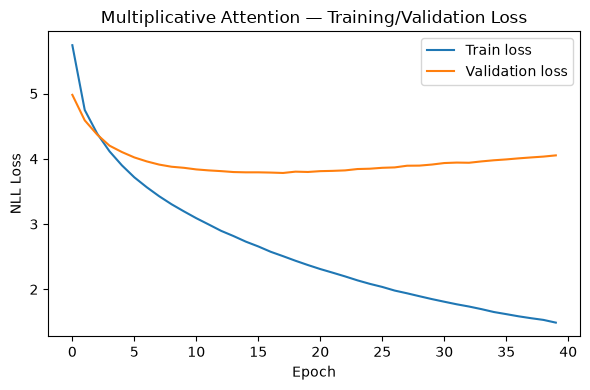

In [6]:
plot_losses(train_losses, val_losses, "Multiplicative Attention — Training/Validation Loss",
            save_path="../outputs/figures/04_multiplicative_loss.png")

In [7]:
evaluateRandomly(encoder, decoder, test_pairs, input_lang, output_lang, n=10, seed=RANDOM_STATE)

> was ist heutzutage nur mit den kindern los ?
= what s going on with children these days ?
< what s your favorite dried fruit ?

> ist das wirklich alles ?
= is that really all ?
< why is that tom s address ?

> hast du pfannkuchen gegessen ?
= did you have pancakes ?
< why did you take your glasses ?

> ich akzeptiere deine bedingungen
= i accept your terms
< i m not going to get drunk

> er ist hier gestern heil angekommen
= he arrived here safely yesterday
< he is a very good at all the station

> viele sind skeptisch
= many people are skeptical
< your pants are liars

> legen sie ihm handschellen an
= cuff him
< there s a lot of traffic on the table

> tom zog die vorhange zu ehe er sich entkleidete
= tom closed the curtains before he got undressed
< tom and mary are bored

> ich wei noch wie wutend du mich gemacht hast
= i remember how angry you made me
< i m not going to buy that

> dieses pedal ist schwergangig
= this pedal is stiff
< it was superb is in danger



In [8]:
def showAttention(input_sentence, output_words, attentions, save_path=None):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.numpy(), cmap='viridis')
    fig.colorbar(cax)
    xlabels = input_sentence.split(' ') + ['<EOS>']
    ax.set_xticks(list(range(len(xlabels)))); ax.set_xticklabels(xlabels, rotation=90)
    ax.set_yticks(list(range(len(output_words)))); ax.set_yticklabels(output_words)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120)
    plt.show()


def evaluateAndShowAttention(input_sentence, save_path=None):
    output_words, attentions = evaluate(encoder, decoder, input_sentence, input_lang, output_lang)
    print('input =', input_sentence); print('output =', ' '.join(output_words))
    showAttention(input_sentence, output_words, attentions[0, :len(output_words), :].detach().cpu(), save_path)

input = die spaghetti die tom macht schmecken mir uberhaupt nicht
output = this doesn t look like that s going <EOS>


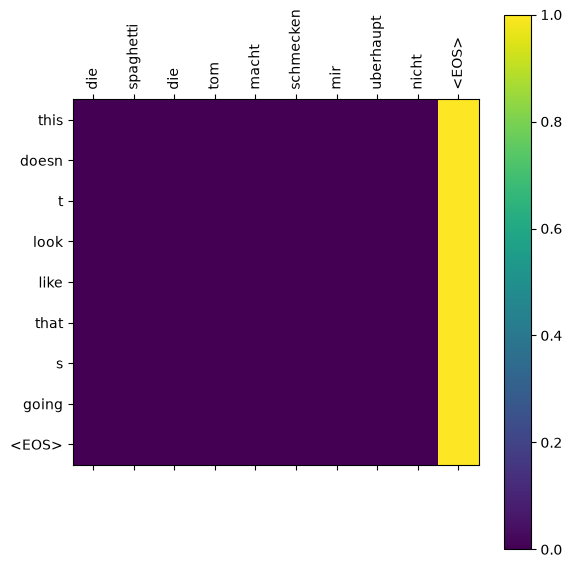

In [9]:
evaluateAndShowAttention(test_pairs[0][0], save_path="../outputs/figures/04_multiplicative_attention_heatmap.png")

In [10]:
bleu = compute_bleu(encoder, decoder, test_pairs, input_lang, output_lang)
print(f"Corpus BLEU-4 (test set, n={len(test_pairs)}): {bleu:.4f}")

Corpus BLEU-4 (test set, n=800): 0.0372


In [11]:

train_ppl = perplexity(train_losses[-1])
val_ppl = perplexity(val_losses[-1])
best_val_ppl = perplexity(min(val_losses))
print(f"Perplexity -> train: {train_ppl:.2f} | val: {val_ppl:.2f} | best val: {best_val_ppl:.2f}")

avg_latency_ms, throughput = measure_inference_latency(encoder, decoder, test_pairs, input_lang, output_lang, n=100)
print(f"Inference latency: {avg_latency_ms:.2f} ms/sentence | Throughput: {throughput:.1f} sentences/sec")

Perplexity -> train: 4.44 | val: 57.56 | best val: 43.95
Inference latency: 2.26 ms/sentence | Throughput: 442.3 sentences/sec


In [12]:
save_result("04_Multiplicative_Attention", {
    "architecture": "Encoder-Decoder + Multiplicative (Luong) Attention",
    "hidden_size": hidden_size, "batch_size": 64, "epochs": EPOCHS,
    "trainable_params": n_params,
    "final_train_loss": train_losses[-1], "final_val_loss": val_losses[-1],
    "train_losses": train_losses, "val_losses": val_losses,
    "test_bleu": bleu, "test_set_size": len(test_pairs),
    "train_perplexity": train_ppl,
    "val_perplexity": val_ppl,
    "best_val_perplexity": best_val_ppl,
    "avg_inference_latency_ms": avg_latency_ms,
    "inference_throughput_sentences_per_sec": throughput
})

Saved results for '04_Multiplicative_Attention' -> d:\NMT_F\nmt-comparison\src\..\outputs\results.json


### Discussion & Conclusion

The Encoder-Decoder model with Multiplicative (Luong) attention was trained for 40 epochs under the same conditions as the other models. The training loss decreased steadily from 5.74 at epoch 1 to 1.48 at epoch 40, while the validation loss decreased from 4.98 to a minimum of approximately 3.79 around epoch 15, after which it gradually increased to 4.05 at epoch 40. This indicates that the model began to overfit after around epoch 15, as training loss continued to decrease while validation loss increased.

The model achieved a Corpus BLEU-4 score of 0.0372 on the held-out test set, showing a clear improvement over both non-attention models: the plain RNN (0.0100) and the Encoder-Decoder without attention (0.0114). However, it performed substantially worse than the Bahdanau attention model (0.1067). This demonstrates that while Multiplicative attention helps the Decoder focus on relevant Encoder hidden states, the type of attention mechanism also has a significant impact on translation quality.

Qualitatively, the model produces some meaningful translations but still generates incorrect or unrelated outputs for many sentences. The attention heatmap (saved to outputs/figures/04_multiplicative_attention_heatmap.png) shows the decoder distributing attention weights across different source positions for each generated word rather than relying on a single fixed context vector. This allows the decoder to focus on relevant parts of the source sequence during translation, demonstrating how multiplicative attention helps overcome the fixed-context limitation.

Overall, the results show the following performance trend: Bahdanau Attention > Multiplicative Attention > Encoder-Decoder > Plain RNN. Thus, attention substantially improves the fixed-context Encoder-Decoder architecture, while Bahdanau attention performed considerably better than Multiplicative (Luong general) attention in this experiments.

